# Лабораторная работа №1 по дисциплине "Основы нейронных сетей"

Выполнили cтуденты группы 3311:
- Шарпинский Денис
- Локтионов Тимофей
- Суздалева Алёна

Требования:
- Количество классов не менее 4

Задачи:
- Разметка изображений
- Обучение CNN (Convolutional Neural Network (CNN or ConvNet))

Датасет: https://www.kaggle.com/datasets/shivanshcoding/1282-pokemon-139542-images-updated-pokedex-dataset?resource=download-directory&select=Pokedex+Image+Dataset

# Импорты

In [12]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import os
import random
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import numpy as np


# Общие положения

Для начала установим, что у нас есть 7890 изображений. От них необходимо отсечь 80% изображений для test группы. Оставшиеся - train группа - необходимо поделить на валидационную и тренировочную выборку. А если точнее: руками распределить часть изображений (от 10 до 20) по 6 папкам - это наши классы. На них учится CNN. Остальные картинки в train группе - вот это и есть валидационная выборка, на которой мы пробуем запускать и проверять нашу нейросеть, а уже только после подпускаем к test группе.

In [17]:
DATASET_DIR = "dataset"
TRAIN_DIR = "dataset/train"
TEST_DIR = "dataset/test"

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

all_images = [f for f in os.listdir(DATASET_DIR)
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.gif'))]

random.seed(42)
random.shuffle(all_images)

split_idx = int(len(all_images) * 0.2)
train_files = all_images[:split_idx]
test_files = all_images[split_idx:]

for f in train_files:
    shutil.move(os.path.join(DATASET_DIR, f), os.path.join(TRAIN_DIR, f))

for f in test_files:
    shutil.move(os.path.join(DATASET_DIR, f), os.path.join(TEST_DIR, f))

print(f"Train: {len(train_files)}")
print(f"Test:  {len(test_files)}")

Train: 0
Test:  0


Found 239 files belonging to 5 classes.
Классы: ['2leg', 'crawl', 'fly', 'manyleg', 'swim']


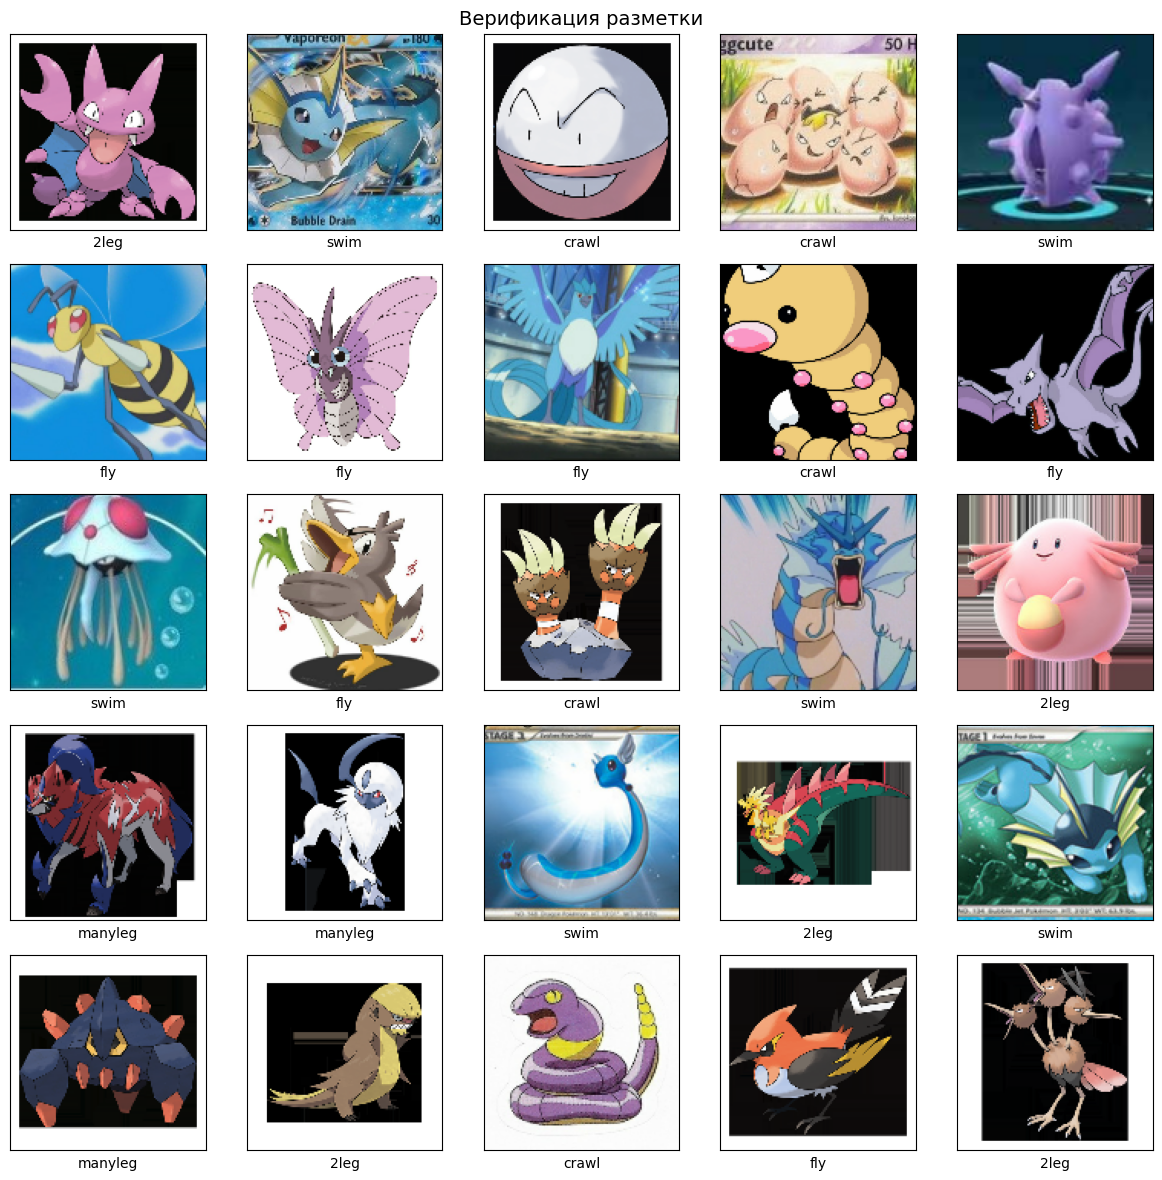

In [18]:
IMG_SIZE = 128
BATCH_SIZE = 32

# Загружаем ТОЛЬКО размеченные картинки (из подпапок)
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

class_names = train_ds.class_names
print(f"Классы: {class_names}")

# Верификация — показываем 25 картинок с подписями классов
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(min(25, len(images))):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.xlabel(class_names[labels[i]])
plt.suptitle("Верификация разметки", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Нормализация пикселей из [0, 255] в [0, 1]
train_ds_normalized = train_ds.map(lambda x, y: (x / 255.0, y))

# Аугментация — "размножает" картинки поворотами/отражениями
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
])
# AlexNet
# Одна из первых глубоких CNN (2012), 5 свёрточных + 3 полносвязных слоя

model_alexnet = tf.keras.Sequential([
    data_augmentation,

    # Conv 1 — большое ядро 11x11, как в оригинале
    tf.keras.layers.Conv2D(96, (11, 11), strides=4, activation='relu',
                           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D((3, 3), strides=2),

    # Conv 2
    tf.keras.layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((3, 3), strides=2),

    # Conv 3
    tf.keras.layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

    # Conv 4
    tf.keras.layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

    # Conv 5
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((3, 3), strides=2),

    # Классификатор
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5)
])

model_alexnet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_alexnet = model_alexnet.fit(train_ds_normalized, epochs=90, verbose=1)

print(f"\nAlexNet финальная accuracy: {history_alexnet.history['accuracy'][-1]:.4f}")

Epoch 1/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.2510 - loss: 2.0388
Epoch 2/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.2678 - loss: 1.5883
Epoch 3/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.2510 - loss: 1.5866
Epoch 4/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2427 - loss: 1.5722
Epoch 5/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2762 - loss: 1.5663
Epoch 6/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.2636 - loss: 1.5725
Epoch 7/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.2552 - loss: 1.5702
Epoch 8/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.2636 - loss: 1.5720
Epoch 9/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2762 - loss: 1.5706
Epoch 10/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.2762 - loss: 1.5641
Epoch 11/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.2845 - loss: 1.5646
Epoch 12/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2636 - loss: 1.568

In [21]:
# VGG16
# 13 свёрточных слоёв (все 3x3) + 3 полносвязных = 16 слоёв

model_vgg16 = tf.keras.Sequential([
    data_augmentation,

    # Блок 1: 2 свёртки по 64 фильтра
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Блок 2: 2 свёртки по 128
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Блок 3: 3 свёртки по 256
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Блок 4: 3 свёртки по 512
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Блок 5: 3 свёртки по 512
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Классификатор
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5)
])

model_vgg16.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_vgg16 = model_vgg16.fit(train_ds_normalized, epochs=30, verbose=1)

print(f"\nVGG16 финальная accuracy: {history_vgg16.history['accuracy'][-1]:.4f}")

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2510 - loss: 1.9319
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2678 - loss: 1.5916
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2762 - loss: 1.5990
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2678 - loss: 1.5734
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2720 - loss: 1.5760
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2803 - loss: 1.5712
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3138 - loss: 1.9577
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2678 - loss: 1.5945
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2678 - loss: 1.5940
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2678 - loss: 1.5833
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2678 - loss: 1.5775
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2678 - loss: 1.5719
Epoch 13/30
8/8 ━━━━━━━━

KeyboardInterrupt: 

In [23]:
# Нормализация пикселей из [0, 255] в [0, 1]
train_ds_normalized = train_ds.map(lambda x, y: (x / 255.0, y))

# Аугментация — "размножает" картинки поворотами/отражениями
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
])

# Архитектура CNN
model = tf.keras.Sequential([
    # Аугментация (работает только при обучении)
    data_augmentation,

    # Блок 1: 32 фильтра
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Блок 2: 64 фильтра
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Блок 3: 128 фильтров
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Классификатор
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5)  # 5 классов
])

# Компиляция
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Обучение
history = model.fit(train_ds_normalized, epochs=90, verbose=1)

# Итог
print(f"\nФинальная accuracy: {history.history['accuracy'][-1]:.4f}")

Epoch 1/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.2301 - loss: 1.9119
Epoch 2/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.2971 - loss: 1.5697
Epoch 3/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.3180 - loss: 1.5522
Epoch 4/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.2929 - loss: 1.5245
Epoch 5/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.3054 - loss: 1.4673
Epoch 6/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.3347 - loss: 1.4582
Epoch 7/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3766 - loss: 1.4395
Epoch 8/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3682 - loss: 1.4129
Epoch 9/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3724 - loss: 1.3630
Epoch 10/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4603 - loss: 1.2873
Epoch 11/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4435 - loss: 1.2899
Epoch 12/90
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4561 - loss: 1.3150
E

In [24]:
TRAIN_DIR = "dataset/train"

# Собираем неразмеченные картинки (те, что лежат россыпью в train/, не в подпапках)
unlabeled_files = [f for f in os.listdir(TRAIN_DIR)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.gif'))]

print(f"Неразмеченных картинок: {len(unlabeled_files)}")

# Загружаем, ресайзим, нормализуем каждую картинку и предсказываем класс
for f in unlabeled_files:
    path = os.path.join(TRAIN_DIR, f)
    img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)  # добавляем размерность batch

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]

    # Перемещаем в папку предсказанного класса
    dst = os.path.join(TRAIN_DIR, predicted_class, f)
    if not os.path.exists(dst):
        os.rename(path, dst)

print("Готово! Все картинки раскиданы по папкам.")

# Проверяем результат
for cls in class_names:
    cls_path = os.path.join(TRAIN_DIR, cls)
    print(f"  {cls:12s} — {len(os.listdir(cls_path))} изображений")

Неразмеченных картинок: 1339
Готово! Все картинки раскиданы по папкам.
  2leg         — 596 изображений
  crawl        — 183 изображений
  fly          — 436 изображений
  manyleg      — 121 изображений
  swim         — 242 изображений
